## Libraries Import

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import torch.nn.functional as F
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np
!pip install ipython-autotime
%load_ext autotime

time: 325 µs (started: 2025-05-23 09:27:05 +00:00)


# Cleaned Data File Import

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving dataset.csv to dataset.csv
time: 18.9 s (started: 2025-05-23 09:27:05 +00:00)


In [ ]:
df = pd.read_csv('dataset.csv')
df.head()

,Units,Area m2,Price per m2,Block_187.0,Block_325.0,Block_326.0,Block_375.0,Block_376.0,Block_390.0,Block_395.0,...,dist_to_park,is_park_within_radius,dist_to_mall,is_mall_within_radius,dist_to_supermarket,is_supermarket_within_radius,dist_to_beach,is_beach_within_radius,dist_to_place_of_worship,is_place_of_worship_within_radius
0,0.2,0.651852,0.246652,0,0,0,0,0,0,0,...,0.079120,0.0,0.880842,0.0,0.033427,1.0,0.450467,0.0,0.197408,0.0
1,0.2,0.650617,0.255311,0,0,0,0,0,0,0,...,0.079120,0.0,0.880842,0.0,0.033427,1.0,0.450467,0.0,0.197408,0.0
2,0.2,0.650617,0.215054,0,0,0,0,0,0,0,...,0.079120,0.0,0.880842,0.0,0.033427,1.0,0.450467,0.0,0.197408,0.0
3,0.0,0.170370,0.119238,0,0,0,0,0,0,0,...,0.732147,0.0,0.903616,0.0,0.675538,0.0,0.499842,0.0,0.332241,0.0
4,0.0,0.170370,0.120038,0,0,0,0,0,0,0,...,0.732147,0.0,0.903616,0.0,0.675538,0.0,0.499842,0.0,0.332241,0.0


time: 130 ms (started: 2025-05-23 09:27:24 +00:00)


In [ ]:
print(df.dtypes)

Units                                float64
Area m2                              float64
Price per m2                         float64
Block_187.0                            int64
Block_325.0                            int64
                                      ...   
is_supermarket_within_radius         float64
dist_to_beach                        float64
is_beach_within_radius               float64
dist_to_place_of_worship             float64
is_place_of_worship_within_radius    float64
Length: 381, dtype: object
time: 1.91 ms (started: 2025-05-23 09:27:24 +00:00)


# Data Splitting

In [ ]:
# target_column = "Price per m2"
# y = df[target_column]
# X = df.drop(columns=[target_column])

# X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.15, random_state=42)

time: 185 µs (started: 2025-05-23 09:27:24 +00:00)


In [ ]:
df = df.dropna()
city_columns = [col for col in df.columns if col.startswith("City_")]
df['city'] = df[city_columns].idxmax(axis=1).str.replace('City_', '')

city_counts = df['city'].value_counts()
valid_cities = city_counts[city_counts > 1].index
df = df[df['city'].isin(valid_cities)].copy()


city_columns = [col for col in df.columns if col.startswith("City_")]

target_column = "Price per m2"
y = df[target_column]
X = df.drop(columns=[target_column])

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=df['city']
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.15, random_state=42,
    stratify=X_train_full['city']
)

X_train = X_train.drop(columns=['city'])
X_val = X_val.drop(columns=['city'])
X_test = X_test.drop(columns=['city'])

time: 47 ms (started: 2025-05-23 09:27:24 +00:00)


In [ ]:
if isinstance(X_train, pd.DataFrame):
    X_train = X_train.values
if isinstance(X_val, pd.DataFrame):
    X_val = X_val.values
if isinstance(X_test, pd.DataFrame):
    X_test = X_test.values

time: 4.06 ms (started: 2025-05-23 09:27:24 +00:00)


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda
time: 30.9 ms (started: 2025-05-23 09:27:24 +00:00)


In [ ]:
X_train = X_train.astype(float)
X_val = X_val.astype(float)
X_test = X_test.astype(float)

X_train = np.array(X_train, dtype=np.float32)
X_val = np.array(X_val, dtype=np.float32)
X_test = np.array(X_test, dtype=np.float32)

X_train_tensor = torch.tensor(X_train.astype(np.float32)).to(device)
X_val_tensor = torch.tensor(X_val.astype(np.float32)).to(device)
X_test_tensor = torch.tensor(X_test.astype(np.float32)).to(device)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1).to(device)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1).to(device)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1).to(device)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

time: 132 ms (started: 2025-05-23 09:27:24 +00:00)


#Model Architecture

In [ ]:
class Model(nn.Module):
    def __init__(self, input_dim):
        super(Model, self).__init__()
        self.model = nn.Sequential(

            # -------------------Ex.1-------------------------- #

            # nn.Linear(input_dim, 512),
            # nn.BatchNorm1d(512),
            # nn.ReLU(),
            # nn.Linear(512, 256),
            # nn.BatchNorm1d(256),
            # nn.ReLU(),
            # nn.Linear(256, 128),
            # nn.ReLU(),
            # nn.Linear(128, 64),
            # nn.ReLU(),
            # nn.Linear(64, 1)

            # -------------------Ex.2-------------------------- #

            # nn.Linear(input_dim, 1024),
            # nn.BatchNorm1d(1024),
            # nn.ReLU(),

            # nn.Linear(1024, 512),
            # nn.BatchNorm1d(512),
            # nn.ReLU(),

            # nn.Linear(512, 256),
            # nn.BatchNorm1d(256),
            # nn.ReLU(),

            # nn.Linear(256, 128),
            # nn.BatchNorm1d(128),
            # nn.ReLU(),

            # nn.Linear(128, 1)

            # -------------------Ex.3-------------------------- #
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, 1)

        )

    def forward(self, x):
        return self.model(x)

time: 1.74 ms (started: 2025-05-23 09:27:24 +00:00)


#Model Hyperparameters

In [ ]:
model = Model(X_train_tensor.shape[1]).to(device)
criterion = nn.MSELoss()
# optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-3)
# optimizer = optim.AdamW(model.parameters(), lr=0.0005, weight_decay=0.001)
optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-3)

from torch.optim.lr_scheduler import StepLR
scheduler = StepLR(optimizer, step_size=10, gamma=0.5)

time: 1.26 s (started: 2025-05-23 09:27:24 +00:00)


#Model Training

In [ ]:
epochs = 50
train_losses = []
val_losses   = []
for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    for batch_X, batch_y in train_loader:
        if batch_X.size(0) == 1:
            continue
        optimizer.zero_grad()
        output = model(batch_X)
        loss = criterion(output, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    average_loss = epoch_loss / len(train_loader)
    train_losses.append(average_loss)

    scheduler.step()

    model.eval()
    with torch.no_grad():
        if X_val_tensor.size(0) > 1:
            val_output = model(X_val_tensor)
            val_loss = criterion(val_output, y_val_tensor).item()
        else:
            val_loss = float('inf')
        val_losses.append(val_loss)

    print(f"Epoch {epoch}, Train Loss: {average_loss:.6f}, Val Loss: {val_loss:.6f}")

Epoch 0, Train Loss: 0.192653, Val Loss: 0.046665
Epoch 1, Train Loss: 0.156513, Val Loss: 0.026111
Epoch 2, Train Loss: 0.130199, Val Loss: 0.017798
Epoch 3, Train Loss: 0.114015, Val Loss: 0.018461
Epoch 4, Train Loss: 0.109454, Val Loss: 0.018124
Epoch 5, Train Loss: 0.099040, Val Loss: 0.011592
Epoch 6, Train Loss: 0.097219, Val Loss: 0.011173
Epoch 7, Train Loss: 0.086721, Val Loss: 0.010084
Epoch 8, Train Loss: 0.083313, Val Loss: 0.011605
Epoch 9, Train Loss: 0.077889, Val Loss: 0.011429
Epoch 10, Train Loss: 0.069747, Val Loss: 0.011169
Epoch 11, Train Loss: 0.073782, Val Loss: 0.010170
Epoch 12, Train Loss: 0.068251, Val Loss: 0.009157
Epoch 13, Train Loss: 0.068300, Val Loss: 0.009215
Epoch 14, Train Loss: 0.070097, Val Loss: 0.009178
Epoch 15, Train Loss: 0.068589, Val Loss: 0.008791
Epoch 16, Train Loss: 0.061308, Val Loss: 0.008935
Epoch 17, Train Loss: 0.059453, Val Loss: 0.008832
Epoch 18, Train Loss: 0.056294, Val Loss: 0.008337
Epoch 19, Train Loss: 0.058190, Val Loss:

#Evaluation

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

model.eval()
with torch.no_grad():
    train_predictions = model(X_train_tensor)
    y_train_pred = train_predictions.cpu().numpy()
    y_train_true = y_train_tensor.cpu().numpy()

    train_rmse = np.sqrt(mean_squared_error(y_train_true, y_train_pred))
    train_mae = mean_absolute_error(y_train_true, y_train_pred)
    train_r2 = r2_score(y_train_true, y_train_pred)

    print(f"\nTrain RMSE: {train_rmse:.6f}")
    print(f"Train MAE: {train_mae:.6f}")
    print(f"Train R²: {train_r2:.4f}")

    val_predictions = model(X_val_tensor)
    y_val_pred = val_predictions.cpu().numpy()
    y_val_true = y_val_tensor.cpu().numpy()

    val_rmse = np.sqrt(mean_squared_error(y_val_true, y_val_pred))
    val_mae = mean_absolute_error(y_val_true, y_val_pred)
    val_r2 = r2_score(y_val_true, y_val_pred)

    print(f"\nVal RMSE: {val_rmse:.6f}")
    print(f"Val MAE: {val_mae:.6f}")
    print(f"Val R²: {val_r2:.4f}")

    test_predictions = model(X_test_tensor)
    y_test_pred = test_predictions.cpu().numpy()
    y_test_true = y_test_tensor.cpu().numpy()

    test_rmse = np.sqrt(mean_squared_error(y_test_true, y_test_pred))
    test_mae = mean_absolute_error(y_test_true, y_test_pred)
    test_r2 = r2_score(y_test_true, y_test_pred)

    print(f"\nTest RMSE: {test_rmse:.6f}")
    print(f"Test MAE: {test_mae:.6f}")
    print(f"Test R²: {test_r2:.4f}")


Train RMSE: 0.079258
Train MAE: 0.058939
Train R²: 0.6378

Val RMSE: 0.086372
Val MAE: 0.059892
Val R²: 0.5781

Test RMSE: 0.091268
Test MAE: 0.063052
Test R²: 0.5519
time: 14.9 ms (started: 2025-05-23 09:27:41 +00:00)


#Graphs

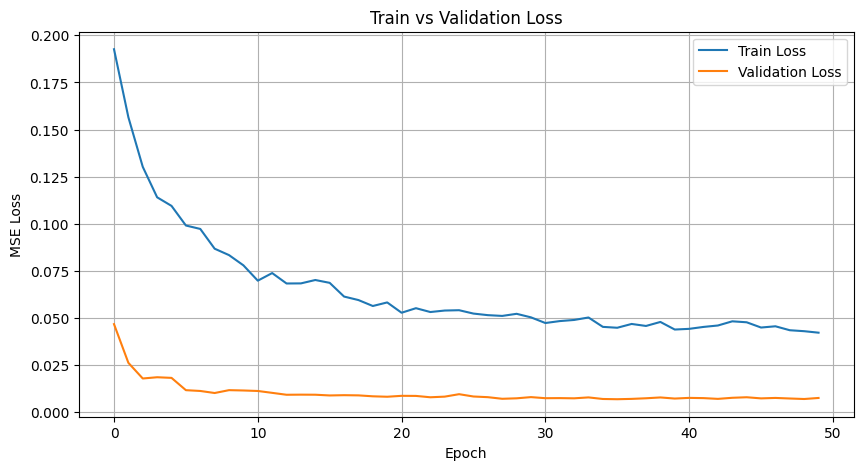

time: 217 ms (started: 2025-05-23 09:27:41 +00:00)


In [ ]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses,   label='Val Loss')
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.title('Loss over Epochs'); plt.legend(); plt.grid(True)

plt.subplot(1,2,2)
plt.plot(train_r2_scores, label='Train R²')
plt.plot(val_r2_scores,   label='Val R²')
plt.xlabel('Epoch'); plt.ylabel('R² Score')
plt.title('R² over Epochs'); plt.legend(); plt.grid(True)
plt.tight_layout()
plt.show()

residuals = truths_test - preds_test
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.hist(residuals, bins=50, edgecolor='k')
plt.title('Residuals Distribution'); plt.xlabel('True - Predicted'); plt.ylabel('Count'); plt.grid(True)

plt.subplot(1,2,2)
plt.scatter(preds_test, residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals vs Predictions'); plt.xlabel('Predicted'); plt.ylabel('Residual'); plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,6))
plt.scatter(truths_test, preds_test, alpha=0.7)
mi, ma = min(truths_test.min(), preds_test.min()), max(truths_test.max(), preds_test.max())
plt.plot([mi,ma],[mi,ma],'k--')
plt.xlabel('True Price per m²'); plt.ylabel('Predicted Price per m²')
plt.title('True vs Predicted'); plt.grid(True)
plt.show()

##Error Testing

In [ ]:
import json
with open("price_minmax.json", "r", encoding="utf-8") as f:
    scaler_data = json.load(f)

price_per_m2_min = scaler_data["price_per_m2_min"]
price_per_m2_max = scaler_data["price_per_m2_max"]

time: 1.01 ms (started: 2025-04-27 11:14:21 +00:00)


In [ ]:
def inverse_transform(normalized_values, min_value, max_value):
    original_values = normalized_values * (max_value - min_value) + min_value
    return original_values

time: 487 µs (started: 2025-04-27 11:14:22 +00:00)


In [ ]:
from sklearn.metrics import mean_absolute_error

model.eval()
with torch.no_grad():
    test_predictions = model(X_test_tensor).cpu().numpy().flatten()
    y_test_true = y_test_tensor.cpu().numpy().flatten()

y_test_pred_original = inverse_transform(test_predictions, price_per_m2_min, price_per_m2_max)
y_test_true_original = inverse_transform(y_test_true, price_per_m2_min, price_per_m2_max)

mae_original = mean_absolute_error(y_test_true_original, y_test_pred_original)
print(f"\nOriginal Scale MAE: {mae_original:.2f} שקלים למ\"ר")


Original Scale MAE: 97.86 שקלים למ"ר
time: 3.21 ms (started: 2025-04-27 11:14:24 +00:00)


In [ ]:
import numpy as np

mean_price_per_m2 = np.mean(y_test_true_original)

mae_percentage = (mae_original / mean_price_per_m2) * 100

print(f"\nMean of Price per m2: {mean_price_per_m2:.2f} שקלים למ\"ר")
print(f"MAE as a percentage of the Mean: {mae_percentage:.2f}%")


Mean of Price per m2: 780.45 שקלים למ"ר
MAE as a percentage of the Mean: 12.54%
time: 1.06 ms (started: 2025-04-27 11:14:27 +00:00)


In [ ]:
from sklearn.metrics import mean_absolute_error
import numpy as np

model.eval()

with torch.no_grad():
    train_predictions = model(X_train_tensor).cpu().numpy().flatten()
    y_train_true = y_train_tensor.cpu().numpy().flatten()

    val_predictions = model(X_val_tensor).cpu().numpy().flatten()
    y_val_true = y_val_tensor.cpu().numpy().flatten()

    test_predictions = model(X_test_tensor).cpu().numpy().flatten()
    y_test_true = y_test_tensor.cpu().numpy().flatten()

y_train_pred_original = inverse_transform(train_predictions, price_per_m2_min, price_per_m2_max)
y_train_true_original = inverse_transform(y_train_true, price_per_m2_min, price_per_m2_max)

y_val_pred_original = inverse_transform(val_predictions, price_per_m2_min, price_per_m2_max)
y_val_true_original = inverse_transform(y_val_true, price_per_m2_min, price_per_m2_max)

y_test_pred_original = inverse_transform(test_predictions, price_per_m2_min, price_per_m2_max)
y_test_true_original = inverse_transform(y_test_true, price_per_m2_min, price_per_m2_max)

mae_train = mean_absolute_error(y_train_true_original, y_train_pred_original)
mae_val = mean_absolute_error(y_val_true_original, y_val_pred_original)
mae_test = mean_absolute_error(y_test_true_original, y_test_pred_original)

print(f"\nTrain MAE: {mae_train:.2f} שקלים למ\"ר")
print(f"Validation MAE: {mae_val:.2f} שקלים למ\"ר")
print(f"Test MAE: {mae_test:.2f} שקלים למ\"ר")

mean_price_per_m2_train = np.mean(y_train_true_original)
mean_price_per_m2_val = np.mean(y_val_true_original)
mean_price_per_m2_test = np.mean(y_test_true_original)

mae_percentage_train = (mae_train / mean_price_per_m2_train) * 100
mae_percentage_val = (mae_val / mean_price_per_m2_val) * 100
mae_percentage_test = (mae_test / mean_price_per_m2_test) * 100

print(f"\nTrain MAE as a percentage of the Mean: {mae_percentage_train:.2f}%")
print(f"Validation MAE as a percentage of the Mean: {mae_percentage_val:.2f}%")
print(f"Test MAE as a percentage of the Mean: {mae_percentage_test:.2f}%")


Train MAE: 80.74 שקלים למ"ר
Validation MAE: 103.98 שקלים למ"ר
Test MAE: 97.86 שקלים למ"ר

Train MAE as a percentage of the Mean: 10.35%
Validation MAE as a percentage of the Mean: 13.80%
Test MAE as a percentage of the Mean: 12.54%
time: 7.5 ms (started: 2025-04-27 11:14:31 +00:00)


#Feature Importance

In [ ]:
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.metrics import r2_score
import torch

class PytorchModelWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, model, device):
        self.model = model
        self.device = device

    def fit(self, X, y=None):
        pass

    def predict(self, X):
        X_tensor = torch.tensor(X, dtype=torch.float32).to(self.device)
        self.model.eval()
        with torch.no_grad():
            predictions = self.model(X_tensor).cpu().numpy().flatten()
        return predictions

time: 1.52 ms (started: 2025-04-22 11:36:22 +00:00)


In [ ]:
from sklearn.model_selection import cross_val_score
import numpy as np

wrapped_model = PytorchModelWrapper(model=model, device=device)

time: 548 µs (started: 2025-04-22 11:36:22 +00:00)


In [ ]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(wrapped_model, X_train, y_train, cv=kf, scoring='r2', n_jobs=-1)

print(f"R² Scores for each fold: {scores}")
print(f"Average R² Score: {np.mean(scores)}")

R² Scores for each fold: [0.93144763 0.94394747 0.94812167 0.93409181 0.93551237]
Average R² Score: 0.9386241898713934
time: 9.14 s (started: 2025-04-22 11:36:22 +00:00)


In [ ]:
from sklearn.inspection import permutation_importance
import pandas as pd

wrapped_model = PytorchModelWrapper(model=model, device=device)

result = permutation_importance(
    wrapped_model,
    X_test,
    y_test,
    scoring="r2",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

feature_importances = pd.DataFrame({
    "Feature": X.columns,
    "Importance Mean": result.importances_mean,
    "Importance Std": result.importances_std
}).sort_values(by="Importance Mean", ascending=False)

print(feature_importances)

                           Feature  Importance Mean  Importance Std
3096           Committee_year_2022         0.102852        0.005189
3095           Committee_year_2021         0.082078        0.003705
3109         City_באר שבע , כלניות         0.076416        0.007550
3098           Committee_year_2024         0.075828        0.004859
3065             Committee_month_1         0.045530        0.002084
...                            ...              ...             ...
3168  City_שדרות , שכונת צפון מרכז        -0.000915        0.000580
1361                 Parcel_1155.0        -0.000933        0.001985
51                   Block_38399.0        -0.001117        0.000309
228                Section_38399.0        -0.001117        0.000309
3114       City_באר שבע , נאות לון        -0.001912        0.000611

[3170 rows x 3 columns]
time: 4min 43s (started: 2025-04-22 11:36:32 +00:00)


# Test environment

In [ ]:
import pandas as pd
import torch
import tkinter as tk
from tkinter import simpledialog, messagebox

time: 59.9 ms (started: 2025-04-20 16:15:56 +00:00)


In [ ]:
uploaded = files.upload()

Saving cleaned_data.csv to cleaned_data (1).csv
time: 34min 24s (started: 2025-04-20 16:15:57 +00:00)


In [ ]:
import json

with open("scaler_minmax.json", "r", encoding="utf-8") as f:
    scaler_minmax = json.load(f)

price_min = scaler_minmax["Price per m2"]["min"]
price_max = scaler_minmax["Price per m2"]["max"]

FileNotFoundError: [Errno 2] No such file or directory: 'scaler_minmax.json'

time: 25.9 ms (started: 2025-04-20 16:50:21 +00:00)


In [ ]:
# בהמשך נכון להסתכל גם על תאריך - שנה כפקטור שמשנה את המחיר

def predict_price(user_input: dict, model, X_columns, scaler_minmax: dict) -> float:
    """
    :param user_input: Dictionary containing input features:
        {
            'City': 'city_name',
            # 'Block': 123,
            # 'Parcel': 456,
            'Area m2': 250
        }
    :param model: DeepFCNN model.
    :param X_columns: Columns from the original training DataFrame.
    :return: Predicted price per square meter.
    """

    # Initialize input df
    input_df = pd.DataFrame([0] * len(X_columns), index=X_columns).T
    input_df.loc[0] = 0

    # Filter user's inputs - separate city and neighborhood
    city = user_input.get('City', None)
    # neighborhood = user_input.get('Neighborhood', None)

    def find_column_by_substring(columns, substring_list):
        """
        :return: Column whose substring is in substring_list >> for city.
        """
        for col in columns:
            if all(sub.lower() in col.lower() for sub in substring_list if sub):
                return col
        return None

    # Finding column contains both city and neighborhood
    if city:
        col_found_city_only = find_column_by_substring(input_df.columns, [city])
        if col_found_city_only:
            input_df[col_found_city_only] = 1
        else:
            print(f"City '{city}' cannot be found in DB.")

    # Precise query with other given parameters.

    if "Area m2" in user_input and "Area m2" in X_columns:
        area_min = scaler_minmax["Area m2"]["min"]
        area_max = scaler_minmax["Area m2"]["max"]
        raw_area = float(user_input["Area m2"])
        if area_max > area_min:
            input_df["Area m2"] = (raw_area - area_min) / (area_max - area_min)
        else:
            input_df["Area m2"] = 0.0

    #Exeption in case no values have got
    if input_df.empty:
        raise ValueError("No records were found match to the query.")

    input_tensor = torch.tensor(input_df.values, dtype=torch.float32).to(device)

    # Prediction
    model.eval()
    with torch.no_grad():
        prediction = model(input_tensor).item()

    price_min = scaler_minmax["Price per m2"]["min"]
    price_max = scaler_minmax["Price per m2"]["max"]
    predicted_price_per_m2 = prediction * (price_max - price_min) + price_min

    return predicted_price_per_m2

In [ ]:
# Example on existing record
user_input = {
    "City": "באר שבע",
    "Area m2": 500
}
predicted_price_per_m2 = predict_price(
    user_input,
    model,
    X.columns,
    scaler_minmax
)

print(f"Predicted price per m²: {predicted_price_per_m2:,.2f} ₪")
total_price = predicted_price_per_m2 * user_input['Area m2']
print(f"\ntotal price for this area size: {total_price:,.2f} ₪")

## Interactive input terminal


In [ ]:
import os

def interactive_terminal(model, X_columns, device, minmax_path="price_minmax.json"):

    if not os.path.exists(minmax_path):
        print(f"Error: file {minmax_path} not found.")
        return

    with open(minmax_path, "r", encoding="utf-8") as f:
        price_range = json.load(f)

    price_per_m2_min = price_range["price_per_m2_min"]
    price_per_m2_max = price_range["price_per_m2_max"]

    while True:
        print("\n------ Land Price Forecast System -------")

        # user input
        city_name = input("Please enter city name [ For example- אשקלון ] or 'Exit':").strip()
        if city_name.lower() == 'exit':
            print ("Closing terminal.")
            break

        area_size_input = input("Please enter Area size in M2: ").strip()
        try:
            area_size = float(area_size_input)
        except ValueError:
            print(f"Area size {area_size_input} is not valid. Try again.")
            continue

        # DataFrame for the receiving values
        # input_df = pd.DataFrame(columns=X_columns)
        input_df = pd.DataFrame([0] * len(X_columns), index=X_columns).T
        input_df.loc[0] = 0
        input_df['Area m2'] = area_size

        city_column = f'City_{city_name}'
        if city_column in input_df.columns:
            input_df[city_column] = 1
        else:
            print(f"City '{city_name}' not found in dataset. Try another.")
            continue

        # input_tensor = torch.tensor(input_df, dtype=torch.float32).to(device)
        input_tensor = torch.tensor(input_df.values, dtype=torch.float32).to(device)

        # Prediction
        model.eval()
        with torch.no_grad():
            prediction = model(input_tensor).item()

        # Inverse transformation

        price_min = scaler_minmax["Price per m2"]["min"]
        price_max = scaler_minmax["Price per m2"]["max"]
        predicted_price_per_m2 = prediction * (price_max - price_min) + price_min

        print(f"\nThe estimated *price per m²*  for {area_size:.0f}m² in {city_name} is: {predicted_price_per_m2:,.2f} ₪")
        break

### Other option for terminal


In [ ]:
# def interactive_terminal(scaler, model, X_columns, device):

#     root = tk.Tk()
#     root.withdraw()

#     city_name = simpledialog.askstring("Input", "הזן את שם העיר:")
#     neighborhood = simpledialog.askstring("Input", "הזן את שם השכונה (לא חובה):")
#     area_size = simpledialog.askfloat("Input", "הזן את גודל השטח במ\"ר:")
#     block = simpledialog.askfloat("Input", "הזן את מספר הגוש (לא חובה):")
#     parcel = simpledialog.askfloat("Input", "הזן את מספר החלקה (לא חובה):")

#     root.destroy()

#     user_input = {
#         'City': city_name,
#         'Neighborhood': neighborhood,
#         'Area m2': area_size,
#         'Block': block,
#         'Parcel': parcel
#     }

#     user_input = {k: v for k, v in user_input.items() if v is not None}

#     try:
#         prediction = predict_price(user_input, scaler, model, X_columns, device)

#         #inverse transformation
#         # StandardScaler
#         original_prediction = prediction * scaler.scale_[-1] + scaler.mean_[-1]

#         # Min- Max Scaler
#         # original_prediction = prediction * (scaler.data_max_[-1] - scaler.data_min_[-1]) + scaler.data_min_[-1]

#         result_root = tk.Tk()
#         result_root.withdraw()
#         messagebox.showinfo("תחזית המחיר",f"The estimated price for M2  is {original_prediction:.2f}")
#         result_root.destroy()

#     except ValueError as e:
#         error_root = tk.Tk()
#         error_root.withdraw()
#         messagebox.showerror("Output Error.", str(e))
#         error_root.destroy()

#     root.destroy()

In [ ]:
# interactive_terminal(DeepFCNN,X.columns, device, minmax_path="price_minmax.json")